In [1]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Define the image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize images to 224x224
    transforms.ToTensor(),           # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet mean and std
])


In [2]:
# Custom dataset class
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (string): Directory with all the images, organized in subfolders per class.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}

        # Scan the root directory to collect image paths and their respective labels
        for idx, class_name in enumerate(sorted(os.listdir(root_dir))):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):  # Only process directories
                self.class_to_idx[class_name] = idx
                for img_name in os.listdir(class_path):
                    img_path = os.path.join(class_path, img_name)
                    if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                        self.image_paths.append(img_path)
                        self.labels.append(idx)
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")  # Ensure image is in RGB format
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
        
        return image, label


In [3]:
# Set your data directory here
#root_dir = r"E:\1 Paper Work\Cutting Tool Paper\Dataset\cutting tool data\test_data_40_images"
root_dir = r"E:\1 Paper Work\Cutting Tool Paper\Dataset\cutting tool data\test_data_40_images"
dataset = CustomImageDataset(root_dir=root_dir, transform=transform)

# Checking the number of samples and class labels
print("Number of samples:", len(dataset))
print("Class to index mapping:", dataset.class_to_idx)


Number of samples: 280
Class to index mapping: {'BF': 0, 'BFI': 1, 'GF': 2, 'GFI': 3, 'N': 4, 'NI': 5, 'TF': 6}


In [4]:
import torch
from torch.utils.data import random_split, DataLoader

# Define the number of support samples per class
support_samples_per_class = 5  # Adjust this number as needed

# Separate the dataset by class for splitting
class_indices = {i: [] for i in range(len(dataset.class_to_idx))}
for idx, (_, label) in enumerate(dataset):
    class_indices[label].append(idx)

# Create support and query indices
support_indices = []
query_indices = []

for class_id, indices in class_indices.items():
    support_indices.extend(indices[:support_samples_per_class])  # First samples for support
    query_indices.extend(indices[support_samples_per_class:])    # Remaining samples for query

# Subset the dataset to create support and query sets
support_set = torch.utils.data.Subset(dataset, support_indices)
query_set = torch.utils.data.Subset(dataset, query_indices)

# Create DataLoaders for both sets
batch_size = 8  # You can adjust this
support_loader = DataLoader(support_set, batch_size=batch_size, shuffle=True)
query_loader = DataLoader(query_set, batch_size=batch_size, shuffle=False)

# Checking the sizes of each set
print("Support set size:", len(support_loader.dataset))
print("Query set size:", len(query_loader.dataset))


Support set size: 35
Query set size: 245


In [5]:
import torch
import torch.nn as nn
import torchvision.models as models

# Define a CNN backbone using ResNet50 for feature extraction
class FeatureExtractor(nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()
        # Load a pre-trained ResNet50 model
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        # Remove the final fully connected layer to get feature embeddings instead of class probabilities
        self.backbone.fc = nn.Identity()
    
    def forward(self, x):
        # Forward pass through the backbone to get feature embeddings
        return self.backbone(x)

# Instantiate the feature extractor model
feature_extractor = FeatureExtractor()

# Test a dummy forward pass
sample_input = torch.randn(1, 3, 224, 224)  # A dummy image with batch size 1
sample_output = feature_extractor(sample_input)

print("Feature embedding size:", sample_output.shape)  # Should be [1, 2048] for ResNet50


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Muhammad Umar/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:08<00:00, 11.6MB/s]


Feature embedding size: torch.Size([1, 2048])


In [6]:
import torch

def compute_prototypes(features, labels, n_classes):
    """
    Compute the prototypes (mean feature vector) for each class in the support set.
    
    Args:
        features (Tensor): Feature embeddings of the support images (shape: [num_support, 512]).
        labels (Tensor): Labels for the support images (shape: [num_support]).
        n_classes (int): Number of classes.
    
    Returns:
        Tensor: Class prototypes (shape: [n_classes, 512]).
    """
    prototypes = []
    for i in range(n_classes):
        class_features = features[labels == i]  # Select features of the current class
        prototype = class_features.mean(0)      # Calculate the mean to get the prototype
        prototypes.append(prototype)
    return torch.stack(prototypes)


In [7]:
def few_shot_classification(model, support_loader, query_loader, n_classes):
    """
    Classify query images based on distances to class prototypes.

    Args:
        model (nn.Module): The feature extractor model.
        support_loader (DataLoader): DataLoader for the support set.
        query_loader (DataLoader): DataLoader for the query set.
        n_classes (int): Number of classes.

    Returns:
        List[int], List[int]: True labels and predicted labels for the query set.
    """
    model.eval()
    with torch.no_grad():
        # Step 1: Extract features and labels for support images
        support_features = []
        support_labels = []
        for images, labels in support_loader:
            features = model(images)
            support_features.append(features)
            support_labels.append(labels)
        
        support_features = torch.cat(support_features)
        support_labels = torch.cat(support_labels)

        # Step 2: Compute class prototypes
        prototypes = compute_prototypes(support_features, support_labels, n_classes)

        # Step 3: Classify query images
        all_true_labels = []
        all_predicted_labels = []
        
        for images, labels in query_loader:
            query_features = model(images)
            dists = torch.cdist(query_features, prototypes)  # Calculate distances to prototypes
            predicted_labels = dists.argmin(dim=1)  # Classify based on nearest prototype
            all_true_labels.extend(labels.cpu().numpy())
            all_predicted_labels.extend(predicted_labels.cpu().numpy())
    
    return all_true_labels, all_predicted_labels


In [8]:
# Set the number of classes
n_classes = len(dataset.class_to_idx)  # 7 classes: BF, BFI, GF, GFI, N, NI, TF

# Run few-shot classification using support and query loaders
true_labels, predicted_labels = few_shot_classification(feature_extractor, support_loader, query_loader, n_classes)

# Check output
print("True labels:", true_labels)
print("Predicted labels:", predicted_labels)


True labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
Predicted labels: [0, 0, 0, 2, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2

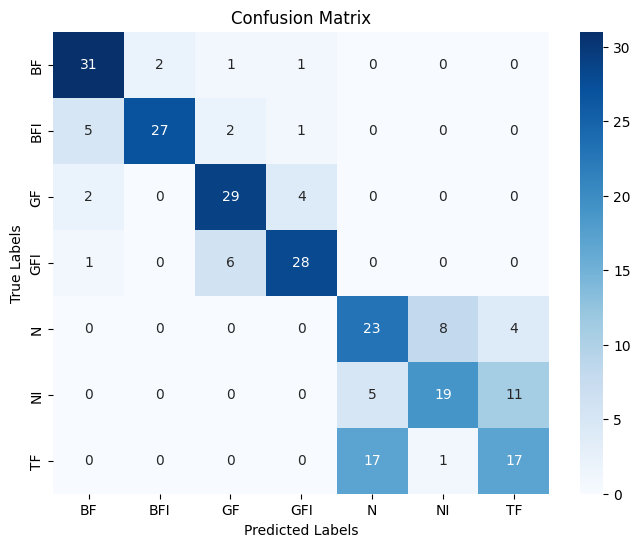

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [10]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(true_labels, predicted_labels, target_names=list(dataset.class_to_idx.keys()))
print(report)

              precision    recall  f1-score   support

          BF       0.79      0.89      0.84        35
         BFI       0.93      0.77      0.84        35
          GF       0.76      0.83      0.79        35
         GFI       0.82      0.80      0.81        35
           N       0.51      0.66      0.57        35
          NI       0.68      0.54      0.60        35
          TF       0.53      0.49      0.51        35

    accuracy                           0.71       245
   macro avg       0.72      0.71      0.71       245
weighted avg       0.72      0.71      0.71       245



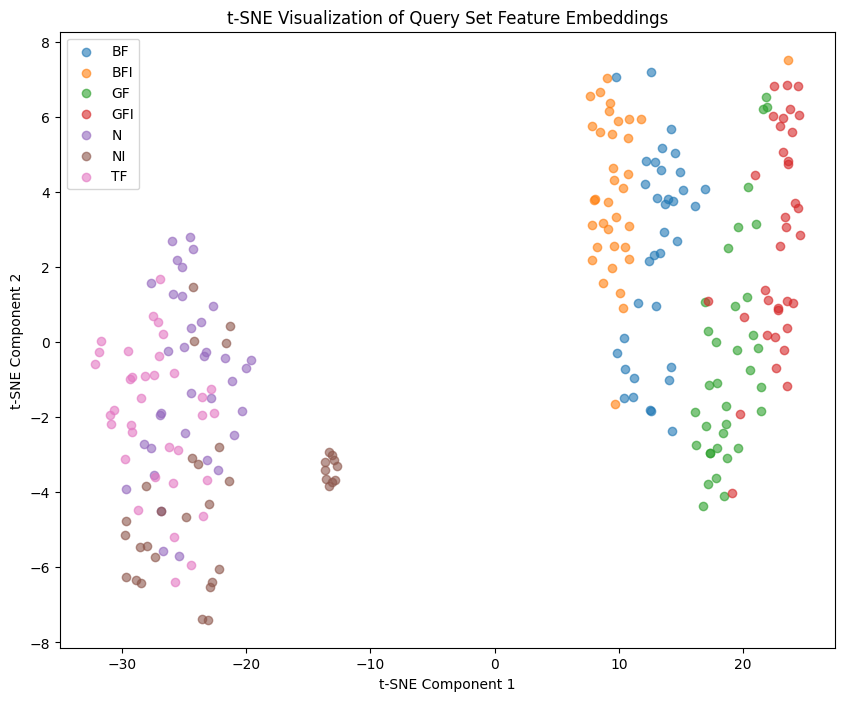

In [11]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Extract feature embeddings and labels for the query set
query_features = []
query_labels = []

feature_extractor.eval()  # Set the feature extractor to evaluation mode
with torch.no_grad():
    for images, labels in query_loader:
        features = feature_extractor(images)  # Get feature embeddings
        query_features.append(features)
        query_labels.extend(labels.cpu().numpy())

# Convert list to tensor for easier manipulation
query_features = torch.cat(query_features).cpu().numpy()
query_labels = np.array(query_labels)

# Apply t-SNE to reduce feature dimensions to 2D
tsne = TSNE(n_components=2, random_state=42)
query_features_2d = tsne.fit_transform(query_features)

# Plot t-SNE result
plt.figure(figsize=(10, 8))
class_names = list(dataset.class_to_idx.keys())  # Get class names for labels
for class_id in np.unique(query_labels):
    indices = query_labels == class_id
    plt.scatter(query_features_2d[indices, 0], query_features_2d[indices, 1], label=class_names[class_id], alpha=0.6)

plt.legend()
plt.title('t-SNE Visualization of Query Set Feature Embeddings')
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


In [12]:
import random

def create_pairs(data_loader):
    """
    Creates pairs of images and labels indicating if they are similar or dissimilar.
    Args:
        data_loader: DataLoader for the dataset.
    
    Returns:
        pairs: List of tuples (image1, image2, label), where label is 1 if similar, 0 if dissimilar.
    """
    pairs = []
    for images, labels in data_loader:
        batch_size = images.size(0)
        for i in range(batch_size):
            image1 = images[i]
            label1 = labels[i]
            
            # Create a similar pair
            similar_idx = random.choice([j for j in range(batch_size) if labels[j] == label1])
            image2_similar = images[similar_idx]
            pairs.append((image1, image2_similar, torch.tensor(1.0)))  # Label 1 for similar pairs
            
            # Create a dissimilar pair
            dissimilar_idx = random.choice([j for j in range(batch_size) if labels[j] != label1])
            image2_dissimilar = images[dissimilar_idx]
            pairs.append((image1, image2_dissimilar, torch.tensor(0.0)))  # Label 0 for dissimilar pairs
            
    return pairs


In [14]:
from torch.utils.data import DataLoader, random_split

# Assuming 'dataset' is already defined and contains the image data
# Define the split ratio and create a train dataset (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Define the DataLoader for the training set
batch_size = 8  # You can adjust the batch size based on available memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Define DataLoader for the validation set if needed
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
# Set up the optimizer
optimizer = torch.optim.Adam(feature_extractor.parameters(), lr=1e-4)

# Training loop with contrastive loss
num_epochs = 5  # Set the number of epochs
for epoch in range(num_epochs):
    feature_extractor.train()
    running_loss = 0.0
    for images, labels in train_loader:
        # Step 1: Create pairs from the batch
        pairs = create_pairs([(images, labels)])
        
        # Step 2: Calculate loss for each pair
        for (img1, img2, pair_label) in pairs:
            # Convert to batches with a single sample each
            img1, img2, pair_label = img1.unsqueeze(0), img2.unsqueeze(0), pair_label.unsqueeze(0)
            
            # Forward pass to get embeddings
            embedding1 = feature_extractor(img1)
            embedding2 = feature_extractor(img2)
            
            # Compute contrastive loss
            loss = contrastive_loss(embedding1, embedding2, pair_label)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("Training complete.")


In [17]:
# Instantiate contrastive loss
contrastive_loss = ContrastiveLoss(margin=1.0)


In [18]:
# Set up the optimizer
optimizer = torch.optim.Adam(feature_extractor.parameters(), lr=1e-4)

# Training loop with contrastive loss
num_epochs = 5  # Set the number of epochs
for epoch in range(num_epochs):
    feature_extractor.train()
    running_loss = 0.0
    for images, labels in train_loader:
        # Step 1: Create pairs from the batch
        pairs = create_pairs([(images, labels)])
        
        # Step 2: Calculate loss for each pair
        for (img1, img2, pair_label) in pairs:
            # Convert to batches with a single sample each
            img1, img2, pair_label = img1.unsqueeze(0), img2.unsqueeze(0), pair_label.unsqueeze(0)
            
            # Forward pass to get embeddings
            embedding1 = feature_extractor(img1)
            embedding2 = feature_extractor(img2)
            
            # Compute contrastive loss
            loss = contrastive_loss(embedding1, embedding2, pair_label)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("Training complete.")


Epoch [1/5], Loss: 0.9532
Epoch [2/5], Loss: 0.9248
Epoch [3/5], Loss: 0.8735
Epoch [4/5], Loss: 0.9170
Epoch [5/5], Loss: 0.8826
Training complete.
